# What does a LangGraph agent do when rates jump 200bps?

**LangGraph** is the agent framework: a graph of nodes with a shared state.
**Tradefloor** is the controlled environment that measures what the agent
does when the world changes.

A historical dataset gives you one realized history. There is no second 2022
in which rates held still, so you cannot ask it what this agent would have
done otherwise.

This notebook creates two worlds that share the same history up to a
checkpoint, changes one variable in one of them, and compares what the same
LangGraph agent does next.

This is an **agent-evaluation** experiment. One seed cannot say which arm was
the better investor. It can say exactly what the same agent, holding the same
book, did differently when one number changed.

## 1. The experiment

Twenty simulated days of shared history, a checkpoint, then a fork. One arm
continues untouched. The other has the policy rate and the corporate bond
yield lifted by 200bps, together, and then runs twenty more days.

The agent is the same object in both arms. `LangGraphAdapter.fork` copies the
decision cadence, the instructions and the graph, so the only thing that
differs between the two worlds is the number that was changed.

Everything the notebook needs is imported from `langgraph/rate_shock.py`, the
script beside it. One definition of the market, so the prose and the script
cannot drift into describing two different experiments.

In [1]:
import json
import sys
from pathlib import Path

import tradefloor as tf
from tradefloor.counterfactual import World, agree, compare

# The production adapter. This notebook implements none of the integration.
# `tradefloor/integrations/langgraph.py` is the source of truth, and this is
# the same object the shipped example and the test suite use.
from tradefloor.integrations import common as ci
from tradefloor.integrations.langgraph import LangGraphAdapter

sys.path.insert(0, str(Path.cwd()))
import rate_shock as experiment

# Live requires an EXPLICIT opt-in on top of the key and the framework. A
# credential in the environment is not consent to spend it, so replay is
# the default even when a live run is possible.
# The key is read where the call is made and never lands in this notebook.
LIVE = experiment.can_run_live()

print(f"tradefloor {tf.__version__}")
print(f"mode        {'live, calling ' + experiment.LIVE_MODEL if LIVE else 'replay'}")
if not LIVE:
    # Asked of the module rather than spelled out here, so a change to what
    # live requires cannot leave a stale sentence in a committed cell.
    print(f"            live would need {experiment.live_requirements()}")

tradefloor 0.8.0
mode        replay
            live would need TRADEFLOOR_LIVE_EXAMPLES=1, ANTHROPIC_API_KEY


## 2. The market

Four companies that differ in the one property deciding rate sensitivity in
this model. Revenue growth is the duration term in the valuation, so the
names are listed longest-duration first and every table below keeps that
order. An alphabetical table would hide the thing under test.

None of them is real. The tickers, the sectors and every fundamental are
generated, so nothing the agent knows about a listed company can help it.

In [2]:
roster = experiment.universe()

experiment.table(
    [[experiment.label(row), row[2], f"{row[7]:.0%}", f"${row[3]:,.2f}",
      f"{row[8]:,.0f}"] for row in experiment.BY_DURATION],
    ["instrument", "what it is", "revenue growth", "price", "avg volume"])

,what it is,revenue growth,price,avg volume
instrument,,,,
NOVA (long-duration),long-duration growth,35%,$112.00,"6,000,000"
HELX (mid-duration),mid-duration growth,18%,$88.00,"4,500,000"
BRDG (short-duration),short-duration cyclical,6%,$70.00,"5,000,000"
STAP (minimal-duration),minimal-duration defensive,1%,$51.00,"4,000,000"


## 3. The agent is a graph, not a prompt

This is what LangGraph brings that a single model call does not. The agent is
two nodes over a shared state:

`analyse` reads the observation and writes down what is worth acting on --
the policy rate, the funding headroom, which names moved. It is a **plain
Python function with no model in it**, and that is deliberate. It makes the
graph one model call per decision instead of two, it is deterministic, and
because it is a pure function of the observation this notebook can recompute
and show its output while replaying, where the graph itself never runs.

`decide` is the model. It receives the observation and the analyst's notes,
and returns a decision.

The offline example in `langgraph/rate_shock.py` builds the same two-node graph
with a plain rule wired in as `decide`. Swapping a rule for a model is one
edge; the state schema, the reducer, the adapter, the validation and the
market are all unchanged.

In [3]:
# Drawn from the compiled graph itself, built here with the RULE decision
# node so it needs no key. The live graph has the same shape and differs
# only in which `decide` is wired in.
#
# Guarded, because this is the one cell that needs LangGraph on a machine
# taking the replay path. The committed output below is what a reader
# without it still sees.
try:
    drawn = experiment.build_graph().get_graph()
    print("nodes: " + ", ".join(n for n in drawn.nodes
                                if not n.startswith("__")))
    print()
    for edge in drawn.edges:
        print(f"   {edge.source} --> {edge.target}")
except ImportError:
    print("langgraph is not installed; the shape is")
    print("   __start__ --> analyse --> decide --> __end__")

nodes: analyse, decide

   __start__ --> analyse
   analyse --> decide
   decide --> __end__


### The state the nodes share

`observation` is where the adapter puts the serialized market view. `notes`
carries a **reducer**, so both nodes append to it rather than overwriting
each other. `decision` is where the graph writes its answer.

The adapter's default input also sends a `messages` key, for graphs built
around a chat model that want the observation as text. This schema does not
declare it, so LangGraph drops it before any node runs. That is not a
workaround; it is what lets one default input serve both kinds of graph.

In [4]:
# `langgraph/rate_shock.py` uses `from __future__ import annotations`, so these
# arrive as strings rather than objects. Unwrapped here, because the reducer
# on `notes` is the part worth seeing.
for key, annotation in experiment.TradeState.__annotations__.items():
    text = getattr(annotation, "__forward_arg__", None) or str(annotation)
    print(f"  {key:<12} {text}")

  observation  dict
  notes        Annotated[list, lambda a, b: a + b]
  decision     Any


## 4. What a live run would cost

Printed before anything is attached, because a **fork** is the one shape
where a reader cannot guess the arithmetic. The shared history is decided
once and both arms inherit it; each arm then decides for itself. So the bill
is the shared days plus the branch days *twice*, not the length of the run.

One call per decision rather than two, because `analyse` is a plain function.

In [5]:
shared, per_arm, total = experiment.live_call_count()

print(f"shared history      {shared:>3} decisions")
print(f"control arm         {per_arm:>3} decisions")
print(f"+200bps arm         {per_arm:>3} decisions")
print(f"                    {'-' * 3}")
print(f"a live run costs    {total:>3} model calls "
      f"of up to {experiment.LIVE_MAX_TOKENS:,} output tokens")
print()
print(f"this run: {'LIVE, spending the above' if LIVE else 'replay, spending nothing'}")

shared history       20 decisions
control arm          20 decisions
+200bps arm          20 decisions
                    ---
a live run costs     60 model calls of up to 2,000 output tokens

this run: replay, spending nothing


## 5. Attaching the agent

Live builds the two-node graph with a model behind `decide` and records every
interaction. Replay loads the recording and needs **no graph, no LangGraph
install, no network and no key** -- the adapter takes `runnable=None` in
replay mode, so the framework is never imported.

The recording is keyed on the exact input the agent was shown. A replay that
misses raises and names the step rather than answering this question with a
response given to a different one.

In [6]:
if LIVE:
    recorder = ci.Transcript()
    agent = experiment.live_agent(recorder=recorder)
    print(f"live against {experiment.LIVE_MODEL}")
else:
    transcript = ci.Transcript.load(experiment.FIXTURE)
    agent = experiment.replay_agent(transcript)
    print(f"replaying {len(transcript)} recorded interactions from")
    print(f"  {experiment.FIXTURE.name}")
    for field in ("framework", "framework_version", "entry_point", "provider",
                  "model", "seed", "warmup_days", "branch_days", "shock_bps"):
        print(f"  {field:<20} {transcript.meta.get(field)}")

agent

replaying 60 recorded interactions from
  rate-shock.json
  framework            langgraph
  framework_version    1.2.12
  entry_point          langgraph.graph.StateGraph
  provider             anthropic
  model                claude-opus-5
  seed                 4242
  warmup_days          20
  branch_days          20
  shock_bps            200


LangGraphAdapter(framework='langgraph', arm='shared', every=6, decisions=0)

In [7]:
# The recording labels which branch each interaction came from, so the file
# can be read a branch at a time. `fork` copies the agent and cannot know
# which arm it became, so the experiment names them right after forking.
if not LIVE:
    from collections import Counter
    print(Counter(e["arm"] for e in transcript.as_dict()["entries"]))

Counter({'shared': 20, 'control': 20, '+200bps': 20})


## 6. Shared history

Twenty days before anything is changed. Both arms inherit this, so whatever
they do afterwards starts from one book and one price history.

Twenty rather than a handful because the observation withholds what it cannot
yet know: `return_5d` is `None` until five days have been observed. A short
warm-up would measure the warm-up.

In [8]:
world = World(seed=experiment.SEED, universe=roster, agent=agent,
              cash=experiment.CASH, pins=experiment.BASE_PINS)
world.run(days=experiment.WARMUP_DAYS)

print(f"day {world.day}, step {world.step}")
print(f"net worth   ${world.portfolio.net_worth(world.engine):,.0f}")
print(f"decisions   {len(agent.record)}")

day 20, step 120
net worth   $51,928,897
decisions   20


### What the analyst node wrote

Recomputed here, not replayed. `analyse` is a pure function of the
observation, so the middle step of the graph is visible even on the replay
path where the graph never ran. This is the payload from the most recent
decision, and the notes are exactly what the model was shown above it.

In [9]:
last = agent.record[-1]
payload = json.loads(last["prompt"].split("OBSERVATION", 1)[1])

for line in experiment.analyst_notes(payload):
    print(f"  - {line}")

  - policy rate 4.00%, corporate bond yield 5.50%
  - equity 51,890,397, gross 0.84x of 2.0x, buying power 60,280,444
  - five-day moves: NOVA -4.2%, HELX -3.9%, STAP -1.2%, BRDG -0.9%


## 7. The two size limits, and which one binds

The observation states both, and an agent that reads one of them is right
until the book changes size.

`max_order_shares` is what the **market** can absorb in one order. It comes
from average daily volume, so it does not move when the portfolio does.
`buying_power` is what the **book** can fund before the leverage cap refuses
the trade. It scales with equity, so it shrinks as the portfolio loses.

Which one is smaller is a property of the run, not a rule. The cell below
computes it from the observation above rather than asserting it, and also
computes the equity at which the two swap places.

An earlier draft of this file ran a $1m book against this same roster. The
participation cap was then worth more than thirty times equity, every order
was refused at the leverage limit, and the run scored zero trades while
looking like it had traded. Four independent agents made that mistake, which
is why `buying_power` is in the observation at all.

In [10]:
book = payload["portfolio"]
cap_notional = sum(a["max_order_shares"] * a["price"] for a in payload["assets"])

print(f"equity                        ${book['net_worth']:,.0f}")
print(f"leverage cap                   {book['max_leverage']}x")
print(f"gross exposure now             {book['gross_exposure']:.2f}x")
print(f"buying power (headroom)       ${book['buying_power']:,.0f}")
print(f"participation cap, all names  ${cap_notional:,.0f}")
print()

binds = "participation" if cap_notional < book["buying_power"] else "funding"
print(f"the participation cap is worth "
      f"{cap_notional / book['net_worth']:.1f}x equity,")
print(f"so on THIS book the {binds} cap binds")

# Buying power is max_leverage x equity minus what is already committed, so
# on a flat book the two limits swap places below this much equity.
crossover = cap_notional / book["max_leverage"]
print(f"they would swap below roughly ${crossover:,.0f} of equity")
print("which is why an agent has to read both rather than pick one")

equity                        $51,890,397
leverage cap                   2.0x
gross exposure now             0.84x
buying power (headroom)       $60,280,444
participation cap, all names  $34,511,400

the participation cap is worth 0.7x equity,
so on THIS book the participation cap binds
they would swap below roughly $17,255,700 of equity
which is why an agent has to read both rather than pick one


## 8. The checkpoint

A Tradefloor checkpoint is the **market**: prices, the order book, the macro
path, the variance process, the generator state.

It is worth being clear that this is not the same thing as a LangGraph
checkpoint, because both projects use the word. A LangGraph checkpoint holds
a graph's channel values and which node runs next. Neither reconstructs the
other, and neither is a save file for the pair.

In [11]:
mark = world.checkpoint(f"before the +{experiment.SHOCK_BPS}bps shock")
mark

Checkpoint('before the +200bps shock', seed=4242, 4 instruments, 180 entries)

## 9. Fork

Two worlds from one checkpoint. Byte-identical at this moment, and each gets
its own copy of the agent -- same graph, same cadence, same instructions.

In [12]:
control, shock = world.fork("control", f"+{experiment.SHOCK_BPS}bps")

report = agree(control, shock)
print(f"identical at the fork: {report.identical}")
print(f"same agent type      : {type(control.agent).__name__}")
print(f"graph object shared  : {control.agent.runnable is shock.agent.runnable}")

identical at the fork: True
same agent type      : LangGraphAdapter
graph object shared  : True


## 10. One intervention

The policy rate and the corporate bond yield, together. Both and not the
policy rate alone, because of how this model transmits: `federal_funds_rate`
reaches a valuation only by steering the corporate bond yield, which is
recomputed at central-bank meetings, the first of which is scheduled past the
end of this run.

Nothing else differs. No news is injected, no volatility is added.

In [13]:
shock.intervene(federal_funds_rate=experiment.SHOCKED_POLICY_RATE,
                corporate_bond_yield=experiment.SHOCKED_DISCOUNT_RATE)

print(f"control    policy {experiment.POLICY_RATE:.2%}, "
      f"discount {experiment.DISCOUNT_RATE:.2%}")
print(f"+200bps    policy {experiment.SHOCKED_POLICY_RATE:.2%}, "
      f"discount {experiment.SHOCKED_DISCOUNT_RATE:.2%}")

control    policy 4.00%, discount 5.50%
+200bps    policy 6.00%, discount 7.50%


## 11. Both worlds continue

Twenty more days each. The agent is asked once a simulated day in both arms.

In [14]:
control.run(days=experiment.BRANCH_DAYS)
shock.run(days=experiment.BRANCH_DAYS)

print(f"control    ${control.portfolio.net_worth(control.engine):,.0f}")
print(f"+200bps    ${shock.portfolio.net_worth(shock.engine):,.0f}")

control    $51,154,025
+200bps    $49,309,249


## 12. The first divergence

The answers below usually land on different steps, and they arrive in causal
order: the macro changed, the agent's stated reasoning changed, its orders
changed, the market it traded changed, the portfolio followed.

The last line is separate from the rest on purpose. A changed rationale says
the agent read the world differently; changed **actions** say it traded on
that reading. Reporting only the first would let a change of mind that never
reached the market read as a change of behaviour.

In [15]:
comparison = compare(control, shock)

print(comparison.divergence.render())
print(f"  {'first different ACTION':<26} "
      f"{experiment.where(experiment.action_divergence(control, shock))}")

  intervention applied       step 120   (day 20)
  macro state differs        step 120   (day 20)
  agent decision differs     step 120   (day 20)
  first different order      step 120   (day 20)
  prices differ              step 120   (day 20)
  portfolio paths differ     step 120   (day 20)
  first different ACTION     step 120   (day 20)


One agent, one book, two worlds that were byte-identical a moment earlier.
This is what it said in each at the first decision after the fork.

In [16]:
print(experiment.divergence_story(control, shock))

  CONTROL  (policy rate 4.00%)

    SELL 20,000 NOVA
    BUY 10,000 HELX
    BUY 20,000 STAP
    HOLD BRDG

    Trim the crowded high-beta NOVA into strength and rotate
    modestly into oversold HELX and defensive STAP to cut beta with
    VIX at 23.5, holding gross near 0.91x.

--------------------------------------------------------------------

  +200BPS  (policy rate 6.00%)

    SELL 20,000 STAP
    SELL 15,000 NOVA
    BUY 20,000 HELX
    HOLD BRDG

    Trim the extended low-growth STAP and shave high-beta NOVA into
    strength, redeploy modestly into oversold, better-valued HELX
    while keeping gross near 0.9x given 6% policy rate and VIX 23.5.


### A note on the sibling notebook

`finrobot/rate_shock.ipynb` runs this same market, this same seed and this
same shock against a different agent, and it got a different answer: identical
trades in both arms, with the rationales differing by a few words.

Both results are legitimate and the pair is worth reading together. What the
two notebooks cannot tell you is **why** they differ. The framework is not the
only thing that changed between them: the model is different, the instructions
are different, and this agent has an analyst node putting the policy rate in
front of the decision in plain language. Any of those could account for it.

Attributing this to LangGraph would be exactly the mistake this environment
exists to prevent. What a controlled experiment gives you is what one agent
did when one number changed. Comparing two agents needs the other variables
held still, and here they were not.

## 13. What changed

In [17]:
rows = [[label, fmt.format(comparison.control[key]),
         fmt.format(comparison.treatment[key])]
        for label, key, fmt in comparison.ROWS if key is not None]

experiment.table(rows, ["metric", "control", "rate shock"])

,control,rate shock
metric,,
final gross exposure,0.84x,0.65x
steps it traded on,20,20
orders sent,51,53
unusable responses,0,0
turnover,"$99,978,653","$103,605,953"
trades filled,51,53
partial fills,0,0
refused trades,0,0
cost against arrival,"$33,197","$37,473"


`Comparison` reports the portfolio in aggregate. That is the right default,
and it hides what this experiment is about: **which** names the agent moved.
Duration order again, because the claim under test is that the response is
monotone in it.

In [18]:
left, right = experiment.weights(control), experiment.weights(shock)
rows = [[experiment.label(row), f"{left.get(row[0], 0.0):.1%}",
         f"{right.get(row[0], 0.0):.1%}",
         f"{right.get(row[0], 0.0) - left.get(row[0], 0.0):+.1%}"]
        for row in experiment.BY_DURATION]

a_sides, b_sides = experiment.sides(control), experiment.sides(shock)
rows.append(["", "", "", ""])
for side in ("BUY", "SELL", "HOLD"):
    rows.append([f"{side} instructions after the fork",
                 str(a_sides[side]), str(b_sides[side]), ""])

experiment.table(rows, ["final weight", "control", "rate shock", "delta"])

,control,rate shock,delta
final weight,,,
NOVA (long-duration),27.6%,19.2%,-8.4%
HELX (mid-duration),22.8%,19.1%,-3.7%
BRDG (short-duration),23.0%,18.7%,-4.3%
STAP (minimal-duration),10.2%,8.2%,-2.0%
,,,
BUY instructions after the fork,28,25,
SELL instructions after the fork,23,28,
HOLD instructions after the fork,29,27,


## 14. Two pictures

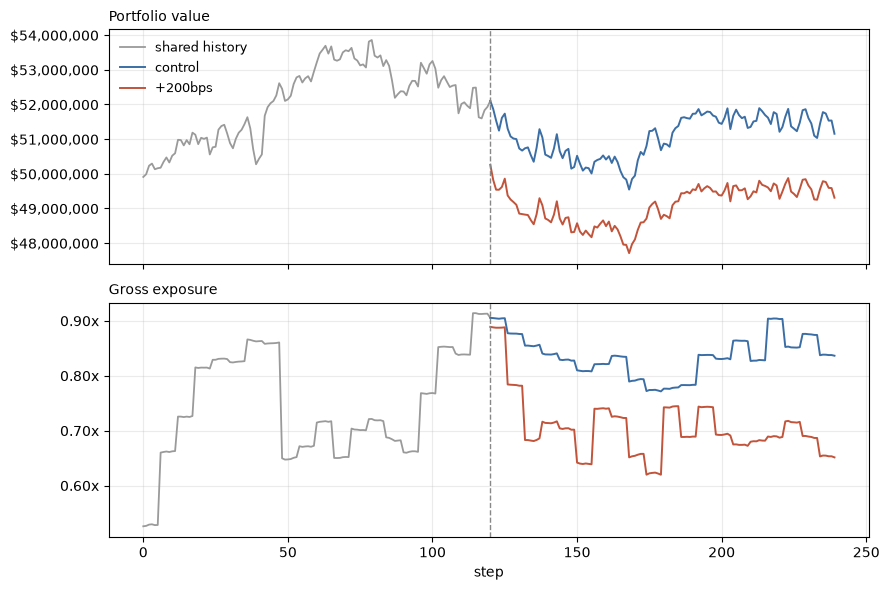

In [19]:
import matplotlib.pyplot as plt

# ASCII punctuation, which is the project's voice and which matplotlib does
# not follow by default: it renders a negative tick with U+2212.
plt.rcParams["axes.unicode_minus"] = False

fork = control.fork_step
steps = [row["step"] for row in control.trace]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, field, title, fmt in (
        (axes[0], "net_worth", "Portfolio value", "${x:,.0f}"),
        (axes[1], "exposure", "Gross exposure", "{x:.2f}x")):
    # The shared history once, in grey. Drawn twice, one arm sits exactly on
    # top of the other and the reader has to wonder which one is hidden.
    ax.plot(steps[:fork + 1], [r[field] for r in control.trace[:fork + 1]],
            color="#9a9a9a", linewidth=1.3, label="shared history")
    for world_, colour, name in ((control, "#3b6ea5", "control"),
                                 (shock, "#c1543a", "+200bps")):
        ax.plot(steps[fork:], [r[field] for r in world_.trace[fork:]],
                color=colour, linewidth=1.4, label=name)
    ax.axvline(fork, color="#888888", linestyle="--", linewidth=1)
    ax.set_title(title, loc="left", fontsize=10)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
axes[1].set_xlabel("step")
fig.tight_layout()
plt.show()

### What it traded

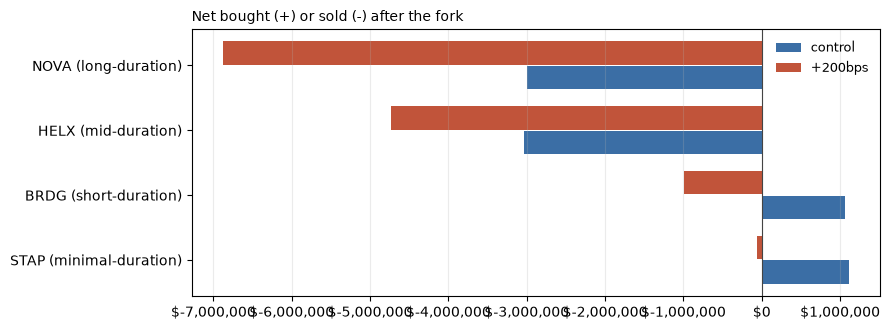

In [20]:
def net_notional(world_):
    fork_ = world_.fork_step or 0
    totals = {t: 0.0 for t in world_.engine.tickers}
    for row in world_.trace[fork_:]:
        for fill in row["fills"]:
            totals[fill["ticker"]] += fill["quantity"] * fill["price"]
    return totals


left_n, right_n = net_notional(control), net_notional(shock)
names = [experiment.label(row) for row in experiment.BY_DURATION]
order = [row[0] for row in experiment.BY_DURATION]
y = range(len(order))

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh([i + 0.19 for i in y], [left_n[t] for t in order], height=0.36,
        color="#3b6ea5", label="control")
ax.barh([i - 0.19 for i in y], [right_n[t] for t in order], height=0.36,
        color="#c1543a", label="+200bps")
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_yticks(list(y), names)
ax.invert_yaxis()
ax.xaxis.set_major_formatter("${x:,.0f}")
ax.set_title("Net bought (+) or sold (-) after the fork", loc="left",
             fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## 15. What Tradefloor knew and the agent did not

Shown **after** the experiment, never before. The boundary means every
decision above was taken without it.

Fair value is the model's own valuation, computed from the same public
fundamentals the agent had and the discount rate it could see. So in
principle the agent could derive it. Handed it directly, the agent would be
inverting the simulator.

In [21]:
rows = []
for row in experiment.BY_DURATION:
    def valued(policy, discount):
        return tf.fair_value(eps=row[5], sector=row[1], revenue_growth=row[7],
                             book_value_per_share=row[6],
                             federal_funds_rate=policy,
                             corporate_bond_yield=discount).fair_value

    a = valued(experiment.POLICY_RATE, experiment.DISCOUNT_RATE)
    b = valued(experiment.SHOCKED_POLICY_RATE,
               experiment.SHOCKED_DISCOUNT_RATE)
    rows.append([experiment.label(row), f"{a:,.2f}", f"{b:,.2f}",
                 f"{b / a - 1:+.1%}"])

print("The graph received none of this.\n")
experiment.table(rows, ["model fair value", "control", "rate shock", "delta"])

The graph received none of this.



,control,rate shock,delta
model fair value,,,
NOVA (long-duration),110.79,104.92,-5.3%
HELX (mid-duration),88.41,84.69,-4.2%
BRDG (short-duration),69.60,67.20,-3.4%
STAP (minimal-duration),50.81,49.22,-3.1%


The valuation falls furthest for the longest-duration name, and the model does
that by construction. The tables above measure whether the agent's own
rotation matched it, without being told that rates were the thing that
changed.

What the graph observed: prices, recent returns, realised volatility, the top
of the book, average daily volume, its own positions and cash, both size
limits, the published macro fields, and public company fundamentals.

What Tradefloor knows about this simulated world: all of that, plus every
company's fair value, the nine-way decomposition of every price move, each
company's mispricing, the generator state and the macro path ahead.

---

## Same starting market. Same LangGraph agent. One controlled intervention.

**Tradefloor measures what the agent actually does differently.**

Ground truth about *this* market, and about no real one. Treat it as a
controlled synthetic experiment. It predicts nothing about how real
securities would react to a real rate rise.

---

LangGraph is a project of
[LangChain](https://github.com/langchain-ai/langgraph), MIT. This is a
Tradefloor integration for LangGraph. LangChain neither maintains nor
endorses it. It is no part of LangGraph's own interface.

The adapter is `tradefloor/integrations/langgraph.py`. The same market as a
runnable script is `langgraph/rate_shock.py`, which also recorded the transcript
this notebook replays. `tests/test_langgraph.py` keeps both honest.